In [1]:
import scanpy as sc
import os 
import scvi
import seaborn as sns
import torch
from rich import print
import numpy as np

adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/six_datasets_4v3_500_1000gene/TH_downsampled_ratio.h5ad")
adata.obs["celltype.L2"].value_counts()
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# 选择第二最多的细胞
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# z只选male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
#去掉名字包含MW22B的样本
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata.obs["celltype.L2"].value_counts()


celltype.L2
MOL-1                      23858
Astrocyte-1                21068
TH Tll1_Thsd7b Glut        19158
MOL-2                      18150
TH Tnc_Cdh20 Glut          16458
TH Car4_Tspan11 Glut       15618
TH Cald1_Gm39185 Glut      12666
TH Fam20a_Fbln1 Glut       12130
TH Kcnk13_Nox4 Glut         8049
OPC                         7460
TH Ccdc192_Gli3 Glut        7451
TH Meis2_Gm2115 GABA        6763
TH Fgf10_Gm16263 Glut       4859
TH Parm1_Mdga1 Glut         4618
MOL-3                       4239
TH Egflam_Fbn2 Glut         3528
TH Tac2_Pde11a Glut         2643
Astrocyte-3                 2281
TH Col27a1_Npsr1 Glut       2077
MFOL                        2015
Astrocyte-4                 1299
Microglia-1                 1095
COP                          909
Endothelial cell             702
Choroid plexus cell          590
Ependymal cell               589
Microglia-2                  584
VLMC                         308
NFOL                         180
Pericyte                     15

In [3]:
# === 3. 数据结构探索（SCVI setup 前置） ===
print(f"shape: {adata_subset.shape}")
print(f"X dtype : {adata_subset.X.dtype}   X range: [{adata_subset.X.min()}, {adata_subset.X.max()}]")
print(f"layers  : {[k for k in adata_subset.layers.keys() if k is not None]}")

# 关键列 value counts —— 与 RUVDEG 一致的元信息
for col in ["status", "company", "celltype.L2", "sex", "sample", "region"]:
    if col in adata_subset.obs.columns:
        vc = adata_subset.obs[col].value_counts()
        print(f"\n{col} (n_unique={vc.size}):")
        print(vc.head(10))


shape: (13885, 16428)

X dtype : float32   X range: [0.0, 1900.0]

layers  : ['counts']

status (n_unique=5):

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

...

sex
M    13885
Name: count, dtype: int64

sample (n_unique=17):

sample
MC25B_TH_yunzhun      1748
CSRS1-3_TH_beirui     1206
CS2-1_TH_beirui       1201
CSRS9-1_TH_beirui     1109
CSRS10-3_TH_beirui    1092
CS1-1_TH_beirui       1033
MW45A_TH_beirui        964
MC50E_TH_beirui        917
MC52B_TH_beirui        795
CS7-3_TH_beirui        714
Name: count, dtype: int64

region (n_unique=1):

region
TH    13885
Name: count, dtype: int64

In [4]:
adata_subset.obs.status.value_counts()

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

In [5]:
adata_subset.layers["counts"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 21352213 stored elements and shape (13885, 16428)>

In [6]:
# === 5. n_genes_on 协变量（mirror RUVDEG cell 4） ===
# 用 raw counts 计算每个细胞 >0 的基因数，标准化后作为连续 nuisance covariate。
# 与 RUVDEG 完全一致：mean/std 由本次数据估计，z-score 后写入 adata.obs["n_genes_on"]。
n_genes_on_raw = (adata_subset.layers["counts"] > 0).sum(axis=1).astype(np.float32)
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std  = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")

adata_subset.obs["n_genes_on"] = (
    (n_genes_on_raw - n_genes_on_mean) / n_genes_on_std
).astype(np.float32)

print(f"raw mean / std    : {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: [{adata_subset.obs['n_genes_on'].min():.3f}, "
      f"{adata_subset.obs['n_genes_on'].max():.3f}]")


/tmp/ipykernel_3349218/1198264137.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs["n_genes_on"] = (


raw mean / std    : 1537.8 / 451.2

standardized range: [-1.996, 5.570]

In [7]:
adata_subset.X = adata_subset.layers["counts"].copy()

In [8]:
# === 6. SCVI setup_anndata（mirror RUVDEG covariate 设计） ===
#
# RUVDEG → SCVI 映射：
#   batch (技术)         -> batch_key="company"
#   n_genes_on (连续)    -> continuous_covariate_keys=["n_genes_on"]
#   group (生物学 status) -> NOT 注册：SCVI 无监督，biology 体现在 latent z；
#                              保留在 adata.obs["status"] 供下游 DEG 使用。
# 不传 labels_key：本数据只含单个 L2 细胞类型，且 labels_key 语义上是细胞类型标签、
# 不是 biology-of-interest，作 covariate-as-label 会语义错误。

BATCH_KEY = "company"
CONT_COVS = ["n_genes_on"]

scvi.model.SCVI.setup_anndata(
    adata_subset,
    layer=None,                              # raw counts 在 adata.X
    batch_key=BATCH_KEY,                     # technical nuisance (RUVDEG `batch`)
    labels_key=None,                         # no cell-type label here
    categorical_covariate_keys=None,         # no extra categorical nuisance
    continuous_covariate_keys=CONT_COVS,     # technical continuous nuisance (RUVDEG `n_genes_on`)
)
print(f"✓ scvi.model.SCVI.setup_anndata complete")
print(f"  manager uuid: {adata_subset.uns['_scvi_manager_uuid'][:8]}…")


✓ scvi.model.SCVI.setup_anndata complete

manager uuid: 1c11bee9…

In [ ]:
model = scvi.model.SCVI(adata_subset, n_layers=2, n_latent=32, gene_likelihood="zinb")
model.train()

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4

Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(data)


Epoch 400/400: 100%|██████████| 400/400 [04:51<00:00,  1.38it/s, v_num=1, train_loss=4.65e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [04:51<00:00,  1.37it/s, v_num=1, train_loss=4.65e+3]


In [ ]:
SCVI_LATENT_KEY = "X_scVI"
adata_subset.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

/tmp/ipykernel_3349218/1273871836.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_subset)


ValueError: Did not find .uns['neighbors']. Run `sc.pp.neighbors` first.

In [25]:
sc.pp.neighbors(adata_subset, use_rep=SCVI_LATENT_KEY)


In [28]:
sc.tl.leiden(adata_subset,key_added=SCVI_LATENT_KEY)

/tmp/ipykernel_3349218/3049849335.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_subset,key_added=SCVI_LATENT_KEY)


In [30]:
adata_subset

AnnData object with n_obs × n_vars = 13885 × 16428
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predi

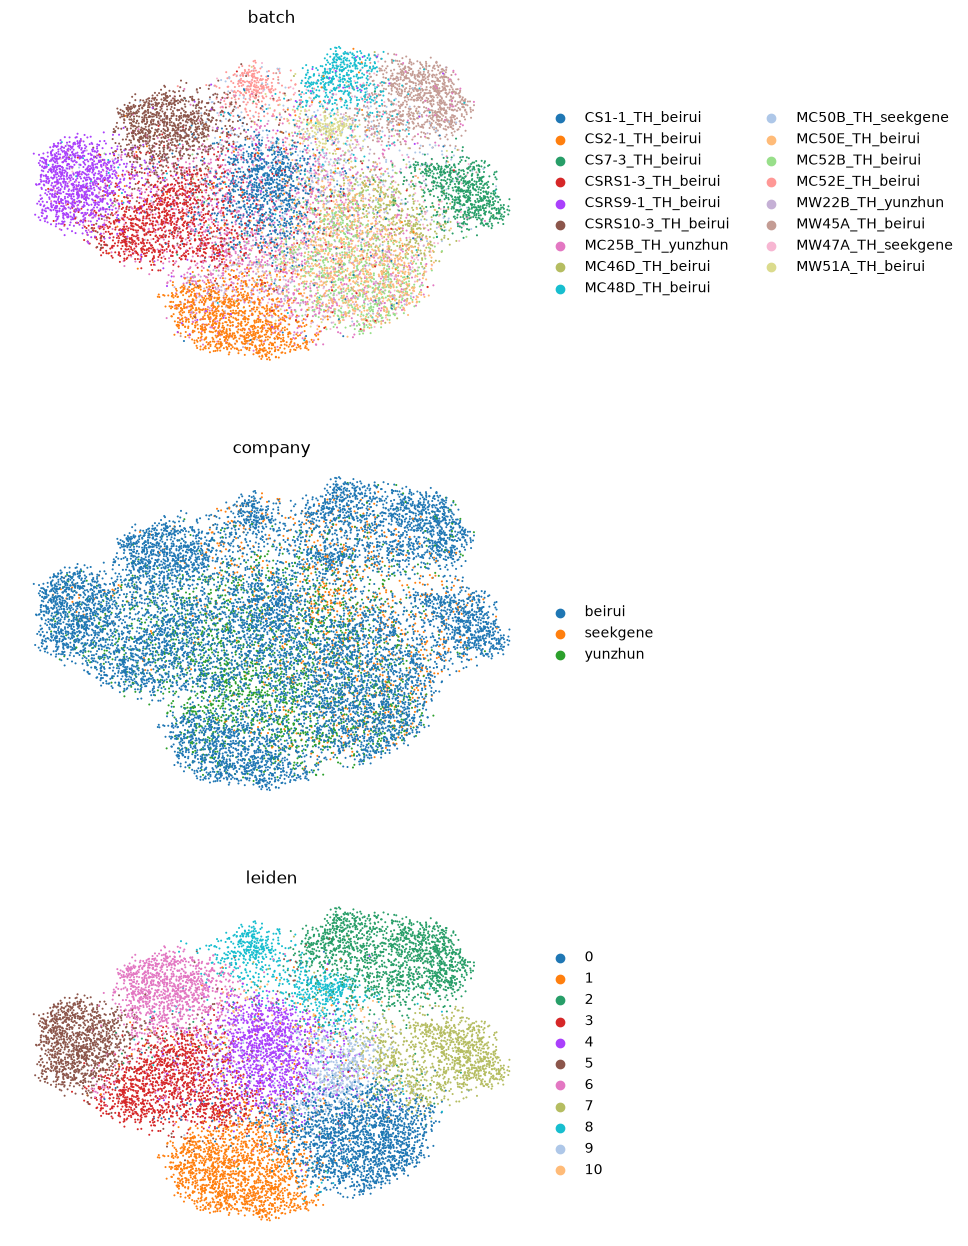

In [35]:
sc.tl.umap(adata_subset, min_dist=0.3,neighbors_key="neighbors")
sc.pl.umap(
    adata_subset,
    color=["batch","company", "leiden"],
    frameon=False,
    ncols=1,
)

In [39]:
deg

,gene,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,...,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2,fdr
0,Gm42418,0.991997,0.008003,4.819877,1.763673e-02,3.408853e-03,5.941328e-09,0.1,2.305570,2.228964,...,8.163993,1.000000,0.963746,348.532928,34.197945,True,CSRES_vs_CON,CSRES,CON,0.991997
1,Lars2,0.988195,0.011805,4.427380,3.526718e-04,1.036937e-04,5.941328e-09,0.1,1.732258,1.703007,...,0.224860,0.776636,0.192490,5.300666,0.958129,True,CSRES_vs_CON,CSRES,CON,0.988255
2,Agmat,0.983393,0.016607,4.081206,1.343522e-07,5.239828e-09,5.941328e-09,0.1,4.496640,4.550275,...,0.000000,0.000881,0.000000,0.002679,0.000000,True,CSRES_vs_CON,CSRES,CON,0.983513
3,Cmss1,0.974390,0.025610,3.638819,5.330375e-04,1.880561e-04,5.941328e-09,0.1,1.631348,1.605738,...,0.377645,0.829175,0.295641,5.923660,1.662898,True,CSRES_vs_CON,CSRES,CON,0.974568
4,Camk1d,0.972589,0.027411,3.569018,1.047852e-03,3.510508e-04,5.941328e-09,0.1,1.605292,1.587319,...,0.763492,0.989727,0.489858,16.322536,3.282801,True,CSRES_vs_CON,CSRES,CON,0.972826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16423,Zcchc7,0.387155,0.612845,-0.459287,4.652749e-04,4.662298e-04,5.941328e-09,0.1,0.016222,0.017365,...,0.923615,0.666275,0.574018,3.755436,4.121948,False,CSRES_vs_CON,CSRES,CON,0.778548
16424,Cdc42bpa,0.385354,0.614646,-0.466883,3.680187e-04,3.648885e-04,5.941328e-09,0.1,0.030800,0.009278,...,0.852401,0.651600,0.540785,3.583697,3.691537,False,CSRES_vs_CON,CSRES,CON,0.778548
16425,Clasp2,0.381953,0.618047,-0.481268,5.639012e-04,5.690361e-04,5.941328e-09,0.1,0.002174,-0.005652,...,1.157964,0.777517,0.653000,5.233714,5.107054,False,CSRES_vs_CON,CSRES,CON,0.778548
16426,Ash1l,0.378551,0.621449,-0.495701,2.966487e-04,2.986886e-04,5.941328e-09,0.1,-0.008553,-0.011025,...,0.593444,0.559730,0.422098,2.673961,2.576447,False,CSRES_vs_CON,CSRES,CON,0.778548


In [38]:
# === 8. DEG 比较（CON 为共同对照组） ===
# status 共 5 类：CON / CURES / CUSUS / CSRES / CSSUS
# 命名约定：C=control stress / S=CSDS stress，末尾 R/S = Resilient / Susceptible
#
# 比较列表：
#   RES_vs_CON    : CURES vs CON        (对照+抗压 vs 对照)
#   SUS_vs_CON    : CUSUS vs CON        (对照+易感 vs 对照)
#   CSDS_vs_CON   : (CSRES ∪ CSSUS) vs CON
#   CSRES_vs_CON  : CSRES vs CON        (CSDS+抗压 vs 对照)

import pandas as pd
from scipy.stats import false_discovery_control

status = adata_subset.obs["status"].astype(str)
print("status counts:")
print(status.value_counts())

adata_de = adata_subset.copy()
adata_de.obs["status_3grp"] = np.where(
    status.isin(["CSRES", "CSSUS"]), "CSDS",
    np.where(status == "CON", "CON", status),
).astype(str)
print("\nstatus_3grp counts:")
print(adata_de.obs["status_3grp"].value_counts())

comparisons = [
    ("RES_vs_CON",    "status",      ["CURES"], "CON"),
    ("SUS_vs_CON",    "status",      ["CUSUS"], "CON"),
    ("CSDS_vs_CON",   "status_3grp", ["CSDS"],  "CON"),
    ("CSRES_vs_CON",  "status",      ["CSRES"], "CON"),
]

deg_results = {}
for label, gb, g1, g2 in comparisons:
    print(f"\n>>> {label}:  {g1} vs {g2}  (groupby={gb})")
    deg = model.differential_expression(
        adata=adata_de,
        groupby=gb,
        group1=g1,
        group2=g2,
        mode="change",
        delta=0.1,
        batch_correction=True,
        silent=False,
    )
    deg = deg.copy()
    deg.index.name = "gene"
    deg = deg.reset_index()
    deg["comparison"] = label
    deg["fdr"] = false_discovery_control(deg["proba_de"].values)
    deg_results[label] = deg

deg_all = pd.concat(deg_results.values(), ignore_index=True)
deg_all.to_csv(
    "/home/junyichen/code/RUVAEDEG/slide_figs/scvi_deg_4comparisons.csv",
    index=False,
)

summary = (
    deg_all.groupby("comparison")
    .agg(
        n_genes=("gene", "size"),
        n_de_fdr05=("fdr", lambda s: int((s < 0.05).sum())),
        n_up_lfc1=(
            "lfc_mean",
            lambda s: int(((deg_all.loc[s.index, "fdr"] < 0.05) & (s > 1)).sum()),
        ),
        n_down_lfc1=(
            "lfc_mean",
            lambda s: int(((deg_all.loc[s.index, "fdr"] < 0.05) & (s < -1)).sum()),
        ),
    )
)
print("\n=== DEG 摘要 ===")
print(summary)

status counts:

status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

status_3grp counts:

status_3grp
CSDS     6355
CUSUS    3049
CON      2317
CURES    2164
Name: count, dtype: int64

>>> RES_vs_CON:  ['CURES'] vs CON  (groupby=status)

...

DE...: 100%|██████████| 1/1 [00:10<00:00, 10.50s/it]


>>> CSRES_vs_CON:  ['CSRES'] vs CON  (groupby=status)

DE...: 100%|██████████| 1/1 [00:07<00:00,  7.65s/it]


=== DEG 摘要 ===

n_genes  n_de_fdr05  n_up_lfc1  n_down_lfc1
comparison                                               
CSDS_vs_CON     16428           0          0            0
CSRES_vs_CON    16428           0          0            0
RES_vs_CON      16428           0          0            0
SUS_vs_CON      16428           0          0            0

In [44]:
deg_all[deg_all.lfc_median.abs() > 0.1].group1.value_counts()

group1
CSRES    13192
CURES    12284
CSDS     12096
CUSUS    11414
Name: count, dtype: int64

In [51]:
model.module

VAE(
  (z_encoder): Encoder(
    (encoder): FCLayers(
      (fc_layers): Sequential(
        (Layer 0): Sequential(
          (0): Linear(in_features=16428, out_features=128, bias=True)
          (1): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): None
          (3): ReLU()
          (4): Dropout(p=0.1, inplace=False)
        )
        (Layer 1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): None
          (3): ReLU()
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (mean_encoder): Linear(in_features=128, out_features=32, bias=True)
    (var_encoder): Linear(in_features=128, out_features=32, bias=True)
  )
  (l_encoder): Encoder(
    (encoder): FCLayers(
      (fc_layers): Sequential(
        (Layer 0): Sequential(
          (0): Linear(in_features

In [57]:
# === SCVI reconstruct counts（真·后验预测抽样） ===
import torch

# 1) 拿到 batch / cov 输入
batch_idx = model.adata_manager.get_from_registry("batch")
cont_cov  = model.adata_manager.get_from_registry("extra_continuous_covs")
cont_cov  = torch.as_tensor(cont_cov, dtype=torch.float32,
                            device=next(model.module.parameters()).device)

# 2) 从后验预测分布 p(x_hat | x) 抽样 n_samples 次
n_samples = 1   # 每细胞 1 个 reconstruction sample
reconstructed = model.posterior_predictive_sample(
    adata=adata_subset,
    n_samples=n_samples,
    batch_size=512,
    silent=False,
)
# 返回 shape: (n_samples, n_cells, n_genes) → squeeze 到 (n_cells, n_genes)
reconstructed = np.asarray(reconstructed).squeeze(0)

print(f"reconstructed shape: {reconstructed.shape}  dtype={reconstructed.dtype}")
print(f"range: [{reconstructed.min()}, {reconstructed.max()}]  median={np.median(reconstructed):.2f}")
print(f"fraction non-zero: {(reconstructed > 0).mean():.3f}")

# 3) 写回 adata
adata_subset.layers["scvi_reconstructed_counts"] = reconstructed

# 4) 同时拿 NB mean（连续值，最常用作"重建"曲线）
norm_mean = model.get_normalized_expression(
    adata=adata_subset,
    library_size="latent",      # 反归一到 latent library size
    return_numpy=True,
    n_samples=1,
)
adata_subset.layers["scvi_reconstructed_mean"] = norm_mean
print(f"NB mean (counts scale) shape: {norm_mean.shape}")
print(f"  range: [{norm_mean.min():.2f}, {norm_mean.max():.2f}]")

ValueError: could not determine the shape of object type 'DataFrame'